# Streamer ecosystem size, by title and by era

**Purpose:** split out of `notebooks/cs_growth_trajectory.ipynb`'s former
§18 (built 2026-09-09, moved out the same day) — the question of how many
distinct people are *streaming* a title, and how many are live at once,
is a cross-title, whole-platform structural question, not specific to
Counter-Strike's own growth story. This notebook asks it directly across
all 23 tracked titles, grouped into the 4 era buckets `docs/
esports_gauses_law_brief.md` and `notebooks/esports_share_of_twitch.ipynb`
already established (Classic 2013-15, Console 2016-20, Second Coming
2021-24, Unclassified).

**Two metrics, both from the Kaggle `Twitch_game_data.csv` import**:
- `Streamers` — distinct monthly channels that streamed the category at
  all that month. Confirmed empirically (in conversation, building the CS
  notebook) to be a genuine unique-count, ~100x larger than `Avg_channels`.
- `Avg_channels` — the average number of channels live *at the same time*
  (a concurrency snapshot, not a unique count).

Together they separate two different things: how big a title's creator
*population* is, versus how much of that population is typically live
simultaneously.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from collectors.kaggle_import import NAME_TO_TITLE_ID

plt.rcParams["figure.dpi"] = 110

KAGGLE_CSV = REPO_ROOT / "data" / "kaggle" / "Twitch_game_data.csv"
raw = pd.read_csv(KAGGLE_CSV, encoding="cp1252")
raw.columns = [c.strip() for c in raw.columns]
raw["year_month"] = raw["Year"].astype(str).str.zfill(4) + "-" + raw["Month"].astype(str).str.zfill(2)
raw["title_id"] = raw["Game"].str.strip().str.lower().map(NAME_TO_TITLE_ID)
matched = raw.dropna(subset=["title_id"]).copy()

## Era grouping

Identical to `esports_share_of_twitch.ipynb`'s `ERA_BY_TITLE` — reused,
not re-derived, so the two notebooks can't silently drift apart on this.

In [2]:
ERA_BY_TITLE = {}
for t in ["league_of_legends", "dota2", "counter_strike", "starcraft2", "hearthstone"]:
    ERA_BY_TITLE[t] = "Classic (2013-15)"
for t in ["rocket_league", "rainbow_six_siege", "overwatch", "tekken", "street_fighter", "mortal_kombat", "guilty_gear"]:
    ERA_BY_TITLE[t] = "Console (2016-20)"
for t in ["valorant", "apex_legends", "fortnite", "pubg", "pubg_mobile", "free_fire", "mobile_legends_bb", "wild_rift", "teamfight_tactics", "brawl_stars"]:
    ERA_BY_TITLE[t] = "Second Coming (2021-24)"
ERA_BY_TITLE["age_of_empires_ii"] = "Unclassified (no era header)"

ERA_ORDER = ["Classic (2013-15)", "Console (2016-20)", "Second Coming (2021-24)", "Unclassified (no era header)"]
TITLES_BY_ERA = {era: [t for t, e in ERA_BY_TITLE.items() if e == era] for era in ERA_ORDER}
for era in ERA_ORDER:
    print(f"{era}: {TITLES_BY_ERA[era]}")

Classic (2013-15): ['league_of_legends', 'dota2', 'counter_strike', 'starcraft2', 'hearthstone']
Console (2016-20): ['rocket_league', 'rainbow_six_siege', 'overwatch', 'tekken', 'street_fighter', 'mortal_kombat', 'guilty_gear']
Second Coming (2021-24): ['valorant', 'apex_legends', 'fortnite', 'pubg', 'pubg_mobile', 'free_fire', 'mobile_legends_bb', 'wild_rift', 'teamfight_tactics', 'brawl_stars']
Unclassified (no era header): ['age_of_empires_ii']


## Coverage — how many months each title has, and why that itself is a finding

The Kaggle top-200 import only includes a title-month if that title
placed in Twitch's top 200 categories that month. A title with fewer
months isn't missing data — it's telling you when (if ever) it got big
enough to place. Read the fighting-game and mobile-title row counts
below with that in mind: thin coverage there is a real extensive-margin
signal (these titles have only recently, if ever, become Twitch-top-200-
relevant), not a data quality problem.

In [3]:
coverage_rows = []
for t, era in ERA_BY_TITLE.items():
    sub = matched[matched["title_id"] == t]
    months = sub["year_month"].nunique()
    years = sorted(sub["year_month"].str[:4].unique())
    coverage_rows.append({
        "title_id": t, "era": era, "months": months,
        "first_year": years[0] if years else None, "last_year": years[-1] if years else None,
    })
coverage_df = pd.DataFrame(coverage_rows).sort_values(["era", "months"], ascending=[True, False])
print(coverage_df.to_string(index=False))

         title_id                          era  months first_year last_year
league_of_legends            Classic (2013-15)     105       2016      2024
            dota2            Classic (2013-15)     105       2016      2024
   counter_strike            Classic (2013-15)     105       2016      2024
       starcraft2            Classic (2013-15)     105       2016      2024
      hearthstone            Classic (2013-15)     105       2016      2024
    rocket_league            Console (2016-20)     105       2016      2024
rainbow_six_siege            Console (2016-20)     105       2016      2024
        overwatch            Console (2016-20)     104       2016      2024
      guilty_gear            Console (2016-20)      25       2021      2024
   street_fighter            Console (2016-20)      20       2022      2024
    mortal_kombat            Console (2016-20)      12       2023      2024
           tekken            Console (2016-20)      11       2023      2024
            

**Read**: every Classic title and 3 of the 7 Console titles
(`rocket_league`, `rainbow_six_siege`, `overwatch`) have near-complete
105/104-month coverage from 2016 onward. The other 4 Console titles are
all fighting games (`tekken`, `street_fighter`, `mortal_kombat`,
`guilty_gear`) and only enter the top-200 in 2021-2023 — 11-25 months
each, despite being "Console (2016-20)"-era titles by release date. That
gap by itself is informative: these titles' *streaming* relevance is
recent, whatever their release-era classification says. Every Second
Coming title has at least partial coverage from its own launch year.

## Distinct monthly streamers, by era — linear scale, all 23 titles

Requested directly by the user (2026-09-09): linear rather than log, so
that a title's true scale is shown honestly rather than visually
compressed — a chart-reading choice already validated on the 6-title
version of this analysis. One panel per era, since scales differ by
orders of magnitude within some eras too (see coverage note above);
forcing all 23 onto one linear axis would flatten everything except
Fortnite to an indistinguishable line at the bottom.

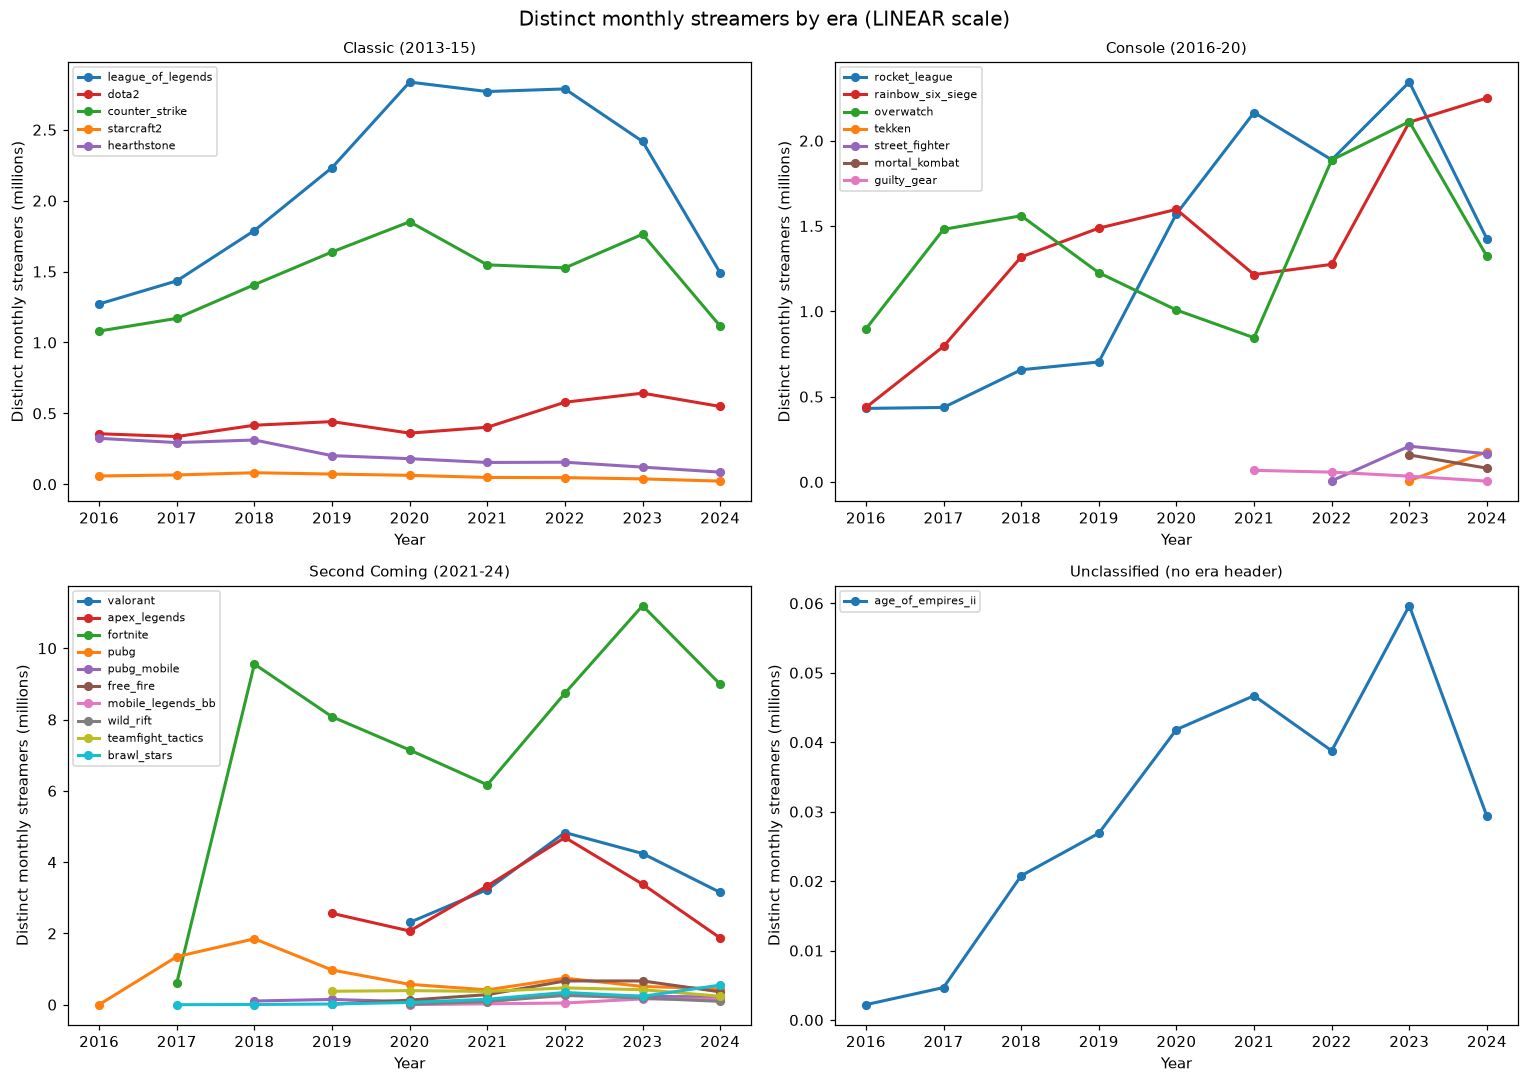

In [4]:
def streamers_by_year(title_id: str) -> pd.DataFrame:
    sub = matched[matched["title_id"] == title_id].copy()
    sub["yr"] = sub["year_month"].str[:4].astype(int)
    yearly = sub.groupby("yr").agg(
        streamers=("Streamers", "sum"), avg_channels=("Avg_channels", "mean"),
    )
    return yearly.reset_index()

PALETTE = [
    "#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]
COLOR_BY_TITLE = {}
for era in ERA_ORDER:
    for i, t in enumerate(TITLES_BY_ERA[era]):
        COLOR_BY_TITLE[t] = PALETTE[i % len(PALETTE)]

def plot_metric_by_era(metric_col: str, ylabel: str, title: str, divisor: float = 1.0, savename: str = None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, era in zip(axes.flat, ERA_ORDER):
        for t in TITLES_BY_ERA[era]:
            df = streamers_by_year(t)
            if df.empty:
                continue
            marker = "o" if len(df) > 1 else "x"
            ax.plot(df["yr"], df[metric_col] / divisor, marker=marker, linestyle="-",
                    color=COLOR_BY_TITLE[t], label=t, linewidth=2, markersize=5)
        ax.set_title(era, fontsize=10)
        ax.set_xlabel("Year")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=7, loc="upper left")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    if savename:
        plt.savefig(REPO_ROOT / "notebooks" / savename, dpi=110)
    plt.show()

plot_metric_by_era(
    "streamers", "Distinct monthly streamers (millions)",
    "Distinct monthly streamers by era (LINEAR scale)",
    divisor=1e6, savename="_streamer_ecosystem_fig1_streamers.png",
)

## Avg concurrent channels live at once, by era — same layout

The concurrency-snapshot counterpart to the chart above. A title can
have a huge unique-streamer population (the chart above) while still
having relatively few live at any given moment, if that population is
spread thin across time — this metric checks that directly rather than
assuming it follows the same shape.

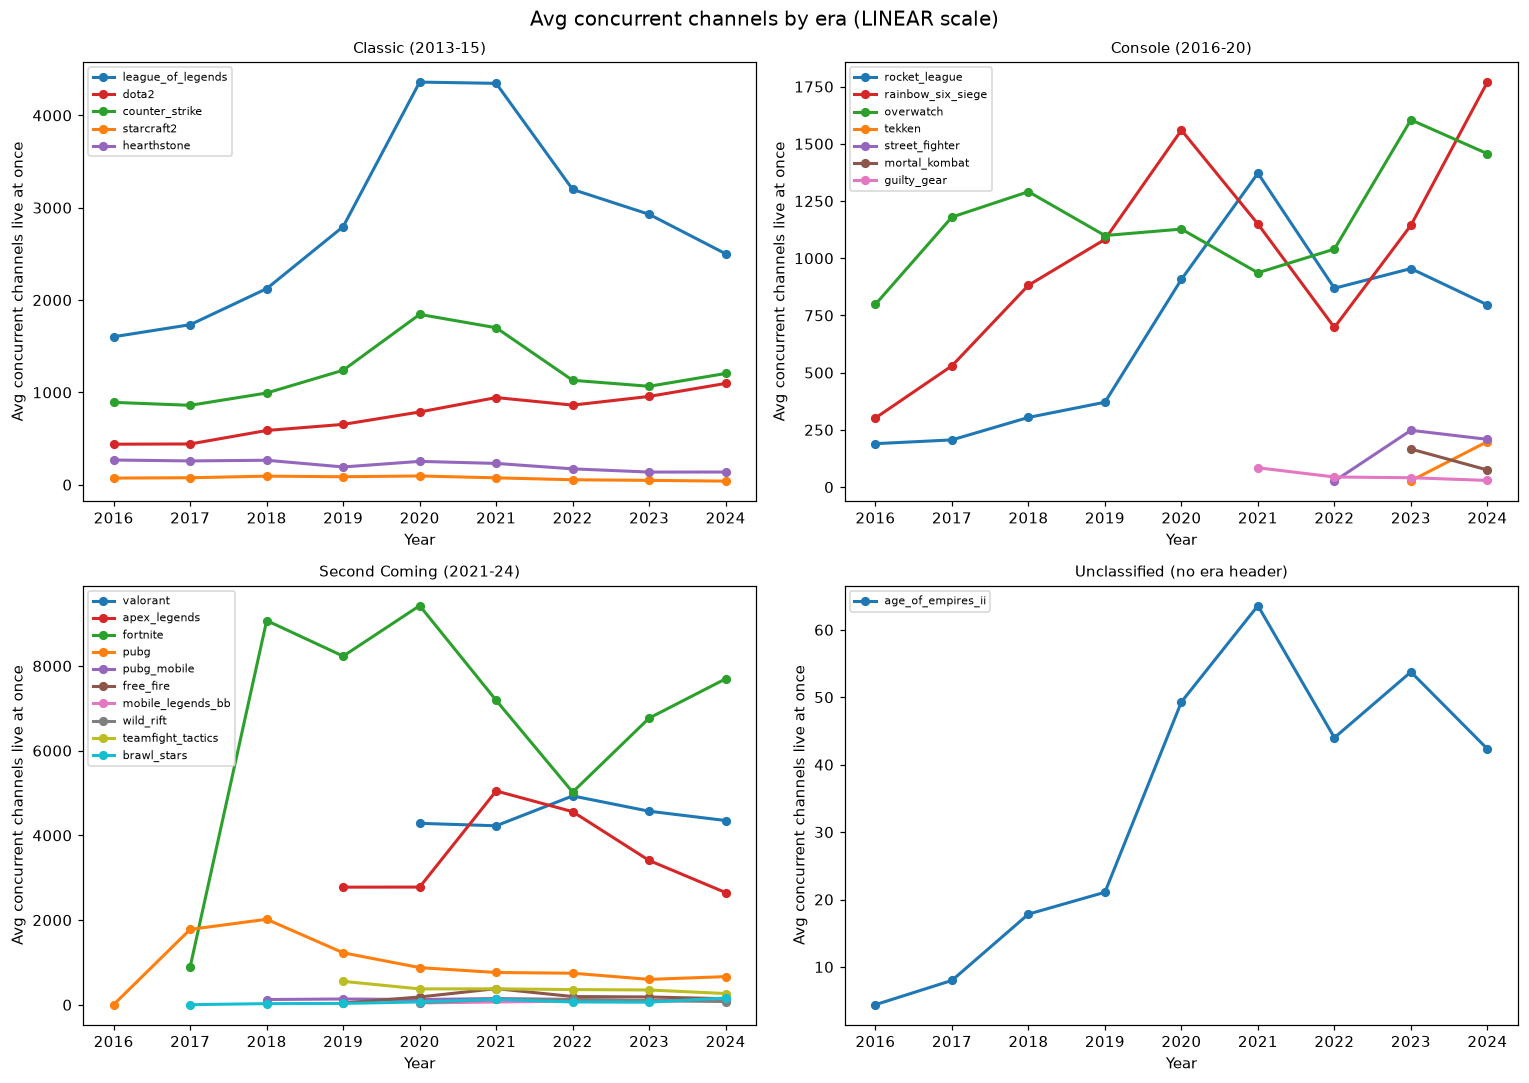

In [5]:
plot_metric_by_era(
    "avg_channels", "Avg concurrent channels live at once",
    "Avg concurrent channels by era (LINEAR scale)",
    divisor=1.0, savename="_streamer_ecosystem_fig2_avg_channels.png",
)

## Peak values, all 23 titles, ranked — the plain numbers behind the charts

In [6]:
peak_rows = []
for t, era in ERA_BY_TITLE.items():
    df = streamers_by_year(t)
    if df.empty:
        continue
    peak_rows.append({
        "title_id": t, "era": era,
        "peak_yearly_streamers": int(df["streamers"].max()),
        "peak_avg_channels": round(float(df["avg_channels"].max()), 0),
    })
peak_df = pd.DataFrame(peak_rows).sort_values("peak_yearly_streamers", ascending=False)
print(peak_df.to_string(index=False))

         title_id                          era  peak_yearly_streamers  peak_avg_channels
         fortnite      Second Coming (2021-24)               11195949             9422.0
         valorant      Second Coming (2021-24)                4829551             4931.0
     apex_legends      Second Coming (2021-24)                4691830             5048.0
league_of_legends            Classic (2013-15)                2836053             4361.0
    rocket_league            Console (2016-20)                2343532             1372.0
rainbow_six_siege            Console (2016-20)                2250026             1770.0
        overwatch            Console (2016-20)                2111577             1605.0
   counter_strike            Classic (2013-15)                1850944             1845.0
             pubg      Second Coming (2021-24)                1849076             2019.0
        free_fire      Second Coming (2021-24)                 666592              382.0
            dota2    

## Findings

**The original 6-title finding (Fortnite/VALORANT/Apex dwarfing CS/Dota2/
League) holds, but only for part of the Second Coming era, not the whole
era.** Ranked by peak yearly streamers: Fortnite (11.2M), VALORANT (4.8M),
and Apex Legends (4.7M) do sit far above every Classic and Console title.
But the *rest* of the Second Coming cohort does not follow — PUBG (1.85M)
is in the same range as Console-era `rocket_league`/`rainbow_six_siege`/
`overwatch` (2.1-2.3M) and Classic-era `counter_strike` (1.85M); `free_fire`
(667K), `brawl_stars` (550K), `teamfight_tactics` (471K), `pubg_mobile`
(294K), `wild_rift` (261K), and `mobile_legends_bb` (162K) all sit at or
below Classic-era `dota2` (642K) and `hearthstone` (324K). **The honest
revision to the earlier hypothesis**: it isn't "newer titles structurally
support bigger creator ecosystems" — it's that a specific handful of
broad-audience, easy-to-clip, high-content-creator-affinity titles
(battle royale and hero-arena shooters built by Epic/Riot/Respawn) have
unusually large creator ecosystems, and several of them happen to be
recent. Mobile MOBAs/battle-royales (`wild_rift`, `mobile_legends_bb`,
`pubg_mobile`, `free_fire`) — despite being just as "new" by era — do
not show the same pattern at all.

**Dota 2 remains the clearest outlier at the bottom of its own era**:
336K-643K distinct streamers is the smallest of any Classic title, and
below several Second Coming and Console titles too, despite total
viewership hours (per the CS/Dota2 lifecycle notebooks) comparable to or
exceeding some of them. That specific contrast — a large audience, a
thin creator base — still stands and is Dota 2-specific within its era,
not a general "old titles have thin ecosystems" pattern (`league_of_
legends`, at 1.3-2.8M, and `counter_strike`, at up to 1.85M, are both
comfortably above it).

**Fighting games' thin `Streamers` coverage (§ Coverage above) confounds
any claim about them here.** Their low peak counts (`tekken` 177K,
`street_fighter` 210K, `mortal_kombat` 158K, `guilty_gear` 68K) could
reflect a genuinely smaller creator ecosystem, or could just be an
artifact of only 11-25 months of top-200 placement to measure from
(versus 60-105 months for most other titles) — this dataset can't
distinguish those two explanations, and neither should be assumed.

**Avg_channels (concurrency) broadly tracks the same story at a
different scale** — Fortnite/VALORANT/Apex reach the thousands, most
Classic and Console titles sit in the hundreds-to-low-thousands, and
Dota 2 stays in the low hundreds — with the same caveat that concurrency
and unique-count can diverge for a title whose population streams in
short, spread-out sessions rather than long overlapping ones (not tested
separately here).

## Cross-references

- `notebooks/cs_growth_trajectory.ipynb` §17a — the `avg_viewer_ratio`
  cross-title-validity correction this notebook's predecessor section was
  built alongside; that correction is about *viewer* metrics, this
  notebook is about *creator* metrics, and they're complementary, not
  duplicates.
- `docs/counter_strike_lifecycle_brief.md` §15 — cites the original
  6-title version of this finding; should be updated to point here and
  reflect the broader-cohort revision above.
- `docs/esports_gauses_law_brief.md` §6 — also cites the original
  6-title finding; same update needed.